<a href="https://colab.research.google.com/github/Nour-Tamimi/BinXtraining/blob/main/Week7/Day3/Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM, Reshape, SimpleRNN
from tensorflow.keras.models import Sequential


base_path = '/content/drive/MyDrive/Sequential Data/'
normal_path = os.path.join(base_path, 'ptbdb_normal.csv')
abnormal_path = os.path.join(base_path, 'ptbdb_abnormal.csv')

train_normal = pd.read_csv(normal_path, header=None)
train_abnormal = pd.read_csv(abnormal_path, header=None)

# 2. SHUFFLE
df = pd.concat([train_normal, train_abnormal], axis=0, ignore_index=True)
df = shuffle(df, random_state=42).reset_index(drop=True)  # حل مشكلة الـ Validation


X = df.drop(columns=[187]).values
y = df[187].values

print("X shape:", X.shape)
print("y shape:", y.shape)

# 3. Train/Test
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)



X shape: (14552, 187)
y shape: (14552,)


In [19]:
print(df[187].value_counts(normalize=True))

187
1.0    0.721963
0.0    0.278037
Name: proportion, dtype: float64


In [26]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# 2. تدريب نموذج SimpleRNN مع EarlyStopping
rnn_model = Sequential([
    Reshape((X_train.shape[1], 1), input_shape=(X_train.shape[1],)),
    SimpleRNN(64),
    Dense(1, activation='sigmoid'),
])

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7252 - loss: 0.5904 - val_accuracy: 0.7042 - val_loss: 0.6246
Epoch 2/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7264 - loss: 0.5886 - val_accuracy: 0.7042 - val_loss: 0.6072
Epoch 3/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7264 - loss: 0.5892 - val_accuracy: 0.7042 - val_loss: 0.6244
Epoch 4/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7217 - loss: 0.5953 - val_accuracy: 0.7042 - val_loss: 0.6096
Epoch 5/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7264 - loss: 0.5896 - val_accuracy: 0.7042 - val_loss: 0.6071
Epoch 6/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7264 - loss: 0.5889 - val_accuracy: 0.7042 - val_loss: 0.6119
Epoch 7/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7264 - loss: 0.5894 - val_accuracy: 0.7042 - val_loss: 0.6085
Epoch 8/30
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7264 - loss: 0.5891 - val_accuracy: 0.70

In [27]:
from tensorflow.keras.optimizers import Adam

lstm_model = Sequential([
    Reshape((X_train.shape[1], 1), input_shape=(X_train.shape[1],)),
    LSTM(64),
    Dense(1, activation='sigmoid'),
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

#Result
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test, verbose=0)
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)

print('\n' + '=' * 50)
print('          RESULTS WITH EARLY STOPPING          ')
print('=' * 50)
print(
    f'SimpleRNN - Stopped at Epoch: {len(rnn_history.history["loss"])} | Test Accuracy: {rnn_acc * 100:.2f}%'
)
print(
    f'LSTM      - Stopped at Epoch: {len(history_lstm.history["loss"])} | Test Accuracy: {lstm_acc * 100:.2f}%'
)
print('=' * 50)

Epoch 1/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.7200 - loss: 0.6041 - val_accuracy: 0.7218 - val_loss: 0.5901
Epoch 2/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.7153 - loss: 0.5531 - val_accuracy: 0.7123 - val_loss: 0.5448
Epoch 3/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - accuracy: 0.7137 - loss: 0.5313 - val_accuracy: 0.7140 - val_loss: 0.5217
Epoch 4/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.7197 - loss: 0.5197 - val_accuracy: 0.7226 - val_loss: 0.5211
Epoch 5/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.7209 - loss: 0.5151 - val_accuracy: 0.7252 - val_loss: 0.5051
Epoch 6/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.7227 - loss: 0.5153 - val_accuracy: 0.7226 - val_loss: 0.5125
Epoch 7/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.7240 - loss: 0.5098 - val_accuracy: 0.7205 - val_loss: 0.5150
Epoch 8/30
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.7271 - loss: 0.5086 - val

### Step 3: Why Order-Awareness and LSTM Gates Matter for ECG Signals

#### 1. The Importance of Sequential Order
An Electrocardiogram (ECG) beat is a continuous time-series signal. A single voltage reading on its own cannot determine whether a heartbeat is normal or abnormal.
The specific sequence and order of the waveform components (such as the P wave, QRS complex, and T wave) are essential for diagnosis. Shuffling or changing the chronological order of these points would completely destroy the diagnostic pattern.

#### 2. Limitations of Plain SimpleRNN
While a standard SimpleRNN processes data sequentially and maintains basic order-awareness, it suffers from the **Vanishing Gradient Problem**.
When processing sequences with many time steps (like 186 data points in this dataset), a SimpleRNN tends to "forget" earlier signal patterns by the time it reaches the end of the sequence.

#### 3. Why LSTMs Perform Better
LSTMs overcome this limitation using specialized **memory cells** regulated by internal **gates**:
* **Forget Gate:** Discards irrelevant noise and unimportant signal fluctuations.
* **Input & Cell Gates:** Selectively remember essential peaks and long-term features across the entire sequence.

These gating mechanisms allow LSTMs to maintain stable gradient flow over all 186 time steps, leading to superior accuracy, better convergence, and stronger generalization on sequential ECG signals.

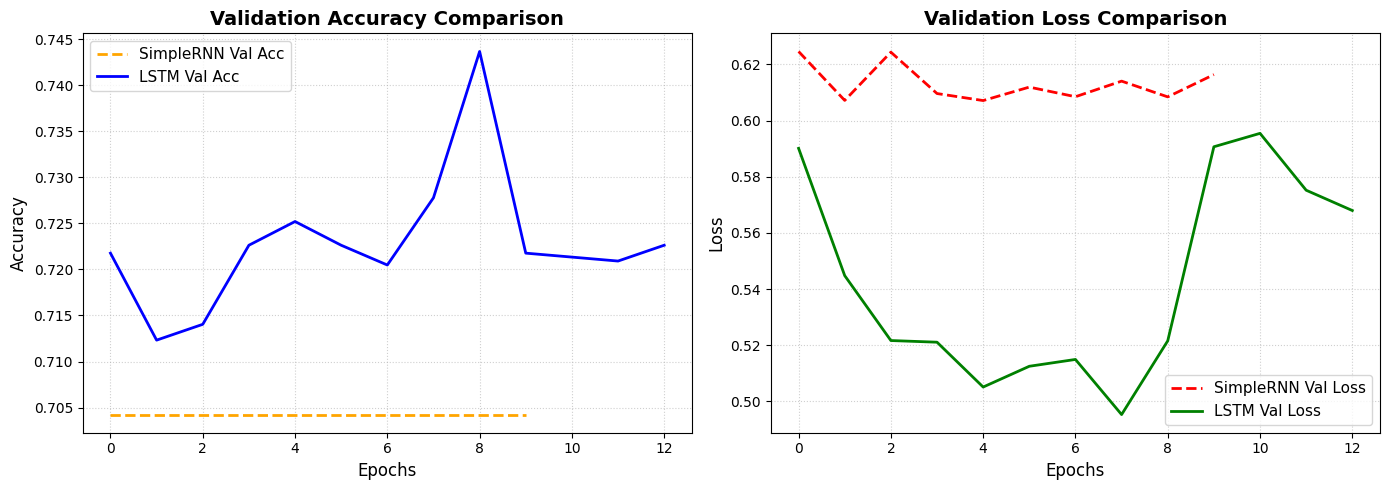

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# (Validation Accuracy)
plt.subplot(1, 2, 1)
plt.plot(
    rnn_history.history['val_accuracy'],
    label='SimpleRNN Val Acc',
    linestyle='--',
    linewidth=2,
    color='orange',
)
plt.plot(
    history_lstm.history['val_accuracy'],
    label='LSTM Val Acc',
    linewidth=2,
    color='blue',
)
plt.title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# 2. (Validation Loss)
plt.subplot(1, 2, 2)
plt.plot(
    rnn_history.history['val_loss'],
    label='SimpleRNN Val Loss',
    linestyle='--',
    linewidth=2,
    color='red',
)
plt.plot(
    history_lstm.history['val_loss'],
    label='LSTM Val Loss',
    linewidth=2,
    color='green',
)
plt.title('Validation Loss Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


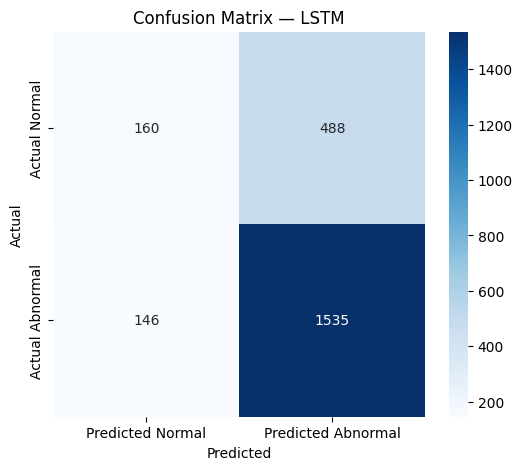

              precision    recall  f1-score   support

      Normal       0.52      0.25      0.34       648
    Abnormal       0.76      0.91      0.83      1681

    accuracy                           0.73      2329
   macro avg       0.64      0.58      0.58      2329
weighted avg       0.69      0.73      0.69      2329



In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_proba = lstm_model.predict(X_val)
y_pred = (y_pred_proba > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Abnormal'],
            yticklabels=['Actual Normal', 'Actual Abnormal'])
plt.title('Confusion Matrix — LSTM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_val, y_pred, target_names=['Normal', 'Abnormal']))

## LSTM Confusion Matrix — Results & Interpretation

|  | Predicted Normal | Predicted Abnormal |
|---|---|---|
| **Actual Normal** | 160 (TN) | 488 (FP) |
| **Actual Abnormal** | 146 (FN) | 1535 (TP) |

**Derived metrics:**
- Overall Accuracy: (160+1535)/2329 ≈ **72.8%**
- Recall on Abnormal: 1535/(1535+146) ≈ **91.3%** — catches most true abnormal heartbeats
- Recall on Normal: 160/(160+488) ≈ **24.7%** — misses most true normal heartbeats, misclassifying them as abnormal

**Interpretation:** Unlike SimpleRNN, this model is no longer just guessing the majority class blindly (it does correctly catch 91% of Abnormal cases). However, it is still heavily biased toward predicting "Abnormal" — three out of every four true Normal heartbeats get misclassified as Abnormal. Overall accuracy (72.8%) looks similar to SimpleRNN's flatline, but the confusion matrix shows this model is doing real, if imbalanced, discrimination rather than a trivial majority-class guess.

**Clinical framing:** high Recall on Abnormal is reassuring (few real problems are missed), but the very low Recall on Normal means many healthy patients would be flagged incorrectly — a cost worth addressing next (e.g. via class weighting or threshold tuning), even though it's a safer failure mode than the reverse.